# Embedder Exploration

This Notebook contains explorations into the usage of the siglip2 embedding model for embedding images into a latent space such that similar objects can be zero-shot classified togethered.

In [1]:
# Install Dependencies
%pip install transformers torch torchvision accelerate matplotlib scikit-learn numpy pandas mediapipe opencv-python chromadb pillow

Note: you may need to restart the kernel to use updated packages.


## Constants

In [1]:
# MODEL = "google/siglip2-so400m-patch14-384"
# MODEL = "facebook/dinov2-base"
MODEL = "openai/clip-vit-base-patch32"

## Embedding a Single Image

In [4]:
import torch
from transformers import AutoModel, AutoProcessor
from transformers.image_utils import load_image
import time

model = AutoModel.from_pretrained(MODEL, device_map="auto").eval()
processor = AutoProcessor.from_pretrained(MODEL)

start = time.time()
image = load_image("./images/rubiks-cube.jpg")
print(f"Image Load Time: {time.time() - start}")

start = time.time()
inputs = processor(images=[image], return_tensors="pt").to(model.device)
print(f"Preprocessor Time: {time.time() - start}")

start = time.time()
with torch.no_grad():
    image_embeddings = model.get_image_features(**inputs)
print(f"Interence Elapsed Time: {time.time() - start}")

print(image_embeddings.shape)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 6d72c285-2d21-40e8-bafe-31762f8eac1e)')' thrown while requesting HEAD https://huggingface.co/google/siglip2-so400m-patch14-384/resolve/main/config.json
Retrying in 1s [Retry 1/5].


Image Load Time: 0.006029367446899414
Preprocessor Time: 0.01711750030517578
Interence Elapsed Time: 1.5399091243743896
torch.Size([1, 1152])


## Batch Embedding

Working with 1 images
Working with 5 images
Working with 10 images
Working with 20 images
Working with 50 images
Number of Images: [1, 5, 10, 20, 50]
Load Times: [0.011829137802124023, 0.0337824821472168, 0.06970858573913574, 0.13350200653076172, 0.3468143939971924]
Preprocessing Times: [0.01642131805419922, 0.07247304916381836, 0.13736987113952637, 0.2713277339935303, 0.682563304901123]
Embedding Times: [0.04650068283081055, 0.09891772270202637, 0.16841530799865723, 0.338054895401001, 0.9674618244171143]


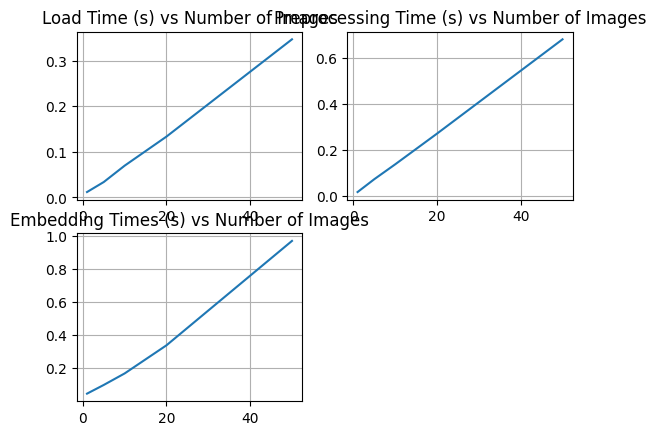

In [18]:
import torch
from transformers import AutoModel, AutoProcessor
from transformers.image_utils import load_image
import matplotlib.pyplot as plt
import time

model = AutoModel.from_pretrained(MODEL, device_map="auto").eval()
processor = AutoProcessor.from_pretrained(MODEL)

x_axis = [1, 5, 10, 20, 50]
load_times = []
preprocessing_times = []
embedding_times = []

for value in x_axis:
    print(f"Working with {value} images")
    images = []
    start = time.time()
    for _ in range(value):
        images.append(load_image("./images/rubiks-cube.jpg"))
    load_times.append(time.time() - start)

    start = time.time()
    inputs = processor(images=images, return_tensors="pt").to(model.device)
    preprocessing_times.append(time.time() - start)

    start = time.time()
    with torch.no_grad():
        image_embeddings = model.get_image_features(**inputs)
    embedding_times.append(time.time() - start)

plt.subplot(221)
plt.plot(x_axis, load_times)
plt.title("Load Time (s) vs Number of Images")
plt.grid(True)

plt.subplot(222)
plt.plot(x_axis, preprocessing_times)
plt.title("Preprocessing Time (s) vs Number of Images")
plt.grid(True)

plt.subplot(223)
plt.plot(x_axis, embedding_times)
plt.title("Embedding Times (s) vs Number of Images")
plt.grid(True)

print(f"Number of Images: {x_axis}")
print(f"Load Times: {load_times}")
print(f"Preprocessing Times: {preprocessing_times}")
print(f"Embedding Times: {embedding_times}")

# Embedding Pick Items Without Hand Clipping / Masking

In [ ]:
import torch
from transformers import AutoModel, AutoProcessor
from transformers.image_utils import load_image
import os
import numpy as np

model = AutoModel.from_pretrained(MODEL, device_map="auto").eval()
processor = AutoProcessor.from_pretrained(MODEL)

images = [load_image(f"../../images/pick-items/{image}") for image in os.listdir("../../images/pick-items")]

inputs = processor(images=images, return_tensors="pt").to(model.device)

with torch.no_grad():
    embeddings = model.get_image_features(**inputs)

embeddings = embeddings.numpy()

shortest_distances = []
for i in range(len(images)):
    shortest_distance = 1e99
    for j in range(len(images)):
        if i == j:
            continue
        dist = np.linalg.norm(embeddings[j] - embeddings[i])
        if dist < shortest_distance:
            shortest_distance = dist
    shortest_distances.append(shortest_distance)

print(f"Shortest Distances: {shortest_distances}")


loading configuration file config.json from cache at /home/n8w3rt/.cache/huggingface/hub/models--google--siglip2-so400m-patch14-384/snapshots/e8e487298228002f3d8a82e0cd5c8ea9c567f57f/config.json
`text_config` is `None`. Initializing the `SiglipTextConfig` with default values.
`vision_config` is `None`. initializing the `SiglipVisionConfig` with default values.
Model config SiglipConfig {
  "initializer_factor": 1.0,
  "model_type": "siglip",
  "text_config": {
    "attention_dropout": 0.0,
    "hidden_act": "gelu_pytorch_tanh",
    "hidden_size": 1152,
    "intermediate_size": 4304,
    "layer_norm_eps": 1e-06,
    "max_position_embeddings": 64,
    "model_type": "siglip_text_model",
    "num_attention_heads": 16,
    "num_hidden_layers": 27,
    "projection_size": 1152,
    "vocab_size": 256000
  },
  "transformers_version": "4.57.1",
  "vision_config": {
    "attention_dropout": 0.0,
    "hidden_act": "gelu_pytorch_tanh",
    "hidden_size": 1152,
    "image_size": 384,
    "intermedi

Shortest Distances: [np.float32(4.019661), np.float32(3.9594655), np.float32(3.4908617), np.float32(3.4042454), np.float32(6.444173), np.float32(4.5590057), np.float32(3.4908617), np.float32(5.1469507), np.float32(5.1469507), np.float32(4.019661), np.float32(5.011322), np.float32(3.4042454), np.float32(4.902116), np.float32(4.2325916)]


/tmp/ipykernel_395468/300790836.py:27: RuntimeWarning: overflow encountered in cast
  if dist < shortest_distance:


## Embedding Pick Items with Hand Clipping

In [2]:
import numpy as np

def hand_pos(landmarks, image):
    if len(landmarks) < 21:
        # need at least 21 for a hand
        return ()

    # center of palm appears to be a better indicator for the location of the hand (more mass concentrated at that point)
    fingers = [[np.array(landmarks[i]) for i in range(j * 4 + 1, j * 4 + 5)] for j in range(5)]
    # base of the palm
    total_x = landmarks[0][0] * image.shape[1]
    total_y = landmarks[0][1] * image.shape[0]
    for finger in fingers:
        # look at base of the finger
        curr = finger[0]
        total_x += (curr[0] * image.shape[1])
        total_y += (curr[1] * image.shape[0])
    return (total_x / 6, total_y / 6)

def hand_bounding_box(landmarks, image):
    left = image.shape[1]
    right = -1
    top = image.shape[0]
    bottom = -1
    for (x, y, _) in landmarks:
        #adjust for pixel values
        x = x * image.shape[1]
        y = y * image.shape[0]
        if x < left:
            # point further left than current left
            left = x
        if x > right:
            # point further right than current right
            right = x
        if y < top:
            #point that is higher than top
            top = y
        if y > bottom:
            bottom = y

    #add a little buffer for the rest of the finger (the landmarks aren't exactly at the tip)
    top, bottom, left, right = int(top - 20), int(bottom + 20), int(left - 20), int(right + 20)
    # return points (top left and clockwise from there, (x, y) for points), size (height, width)
    return ((left, top), (right, top), (right, bottom), (left, bottom)), (bottom - top, right - left)


In [3]:
import mediapipe as mp
from matplotlib import pyplot as plt
import cv2
import copy

def draw_hand(image):
    mp_drawing = mp.solutions.drawing_utils
    mp_hands = mp.solutions.hands
    hands = mp_hands.Hands(min_detection_confidence=0.7, min_tracking_confidence=0.3, max_num_hands=2)
    results = hands.process(image)
    draw_image = copy.deepcopy(image)

    hand_points = []
    if results.multi_hand_landmarks:
        for (i, hand_landmarks) in enumerate(results.multi_hand_landmarks):
            mp_drawing.draw_landmarks(draw_image, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            points = []
            for i in hand_landmarks.landmark[:21]:
                points.append([i.x, i.y, i.z])
            hand_points.append(points)

    hand_positions = [hand_pos(hand_point, image) for hand_point in hand_points]
    left_hand_points = None
    left_hand_position = (1e99, 1e99)
    for (i, hand_position) in enumerate(hand_positions):
        if hand_position[0] < left_hand_position[0]:
            left_hand_position = hand_position
            left_hand_points = hand_points[i]

    bounding_box, bounding_box_size = hand_bounding_box(left_hand_points, image)
    for point_index in range(len(bounding_box)):
        cv2.line(draw_image, bounding_box[point_index], bounding_box[(point_index + 1) % len(bounding_box)], (0, 0, 255), 4)

    plt.imshow(draw_image)
    plt.show()

    plt.imshow(image[bounding_box[0][1]:bounding_box[2][1], bounding_box[0][0]:bounding_box[2][0]])
    plt.show()

    return image[bounding_box[0][1]:bounding_box[2][1], bounding_box[0][0]:bounding_box[2][0]]


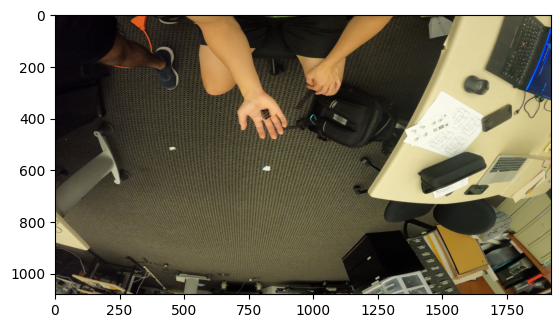

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

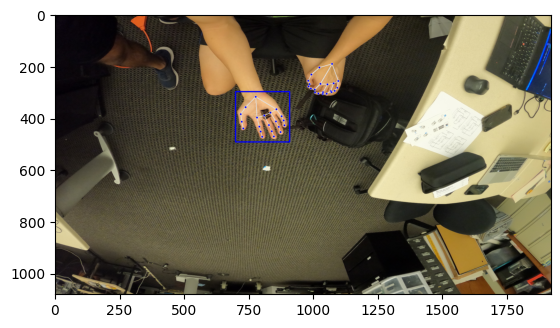

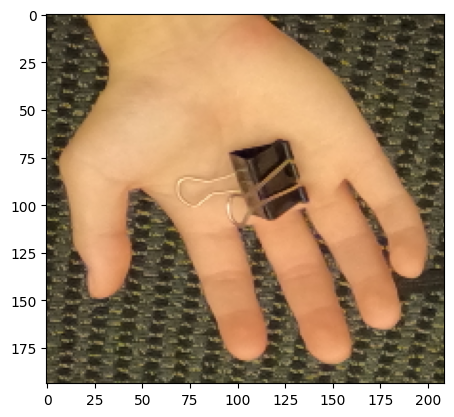

In [27]:
import cv2
from matplotlib import pyplot as plt

image = cv2.imread("../../images/pick-items/alligatorclip.JPG")
image = cv2.resize(image, (1920, 1080))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()
hand = draw_hand(image)

In [4]:
import mediapipe as mp

def segment_hand(image):
    mp_hands = mp.solutions.hands
    hands = mp_hands.Hands(min_detection_confidence=0.7, min_tracking_confidence=0.3, max_num_hands=2)
    results = hands.process(image)

    hand_points = []
    if results.multi_hand_landmarks:
        for (i, hand_landmarks) in enumerate(results.multi_hand_landmarks):
            points = []
            for i in hand_landmarks.landmark[:21]:
                points.append([i.x, i.y, i.z])
            hand_points.append(points)
    else:
        return None

    if len(hand_points) > 1:
        hand_positions = [hand_pos(hand_point, image) for hand_point in hand_points]
        right_hand_points = None
        right_hand_position = (1e99, 1e99)
        for (i, hand_position) in enumerate(hand_positions):
            if hand_position[0] < right_hand_position[0]:
                right_hand_position = hand_position
                right_hand_points = hand_points[i]
    else:
        right_hand_points = hand_points[0]

    bounding_box, _ = hand_bounding_box(right_hand_points, image)

    return image[bounding_box[0][1]:bounding_box[2][1], bounding_box[0][0]:bounding_box[2][0]]


In [5]:
import numpy as np

def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

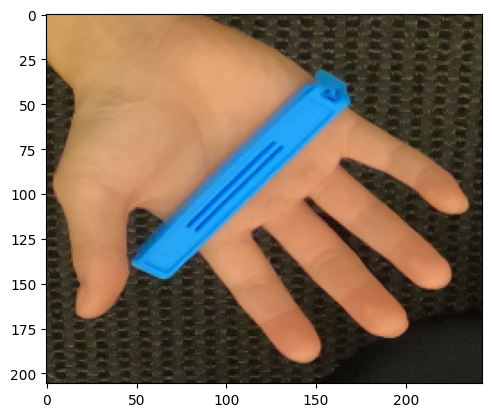

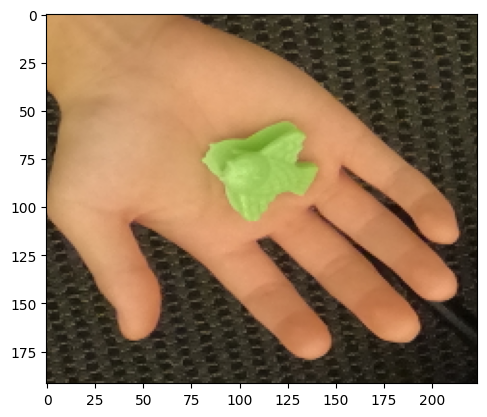

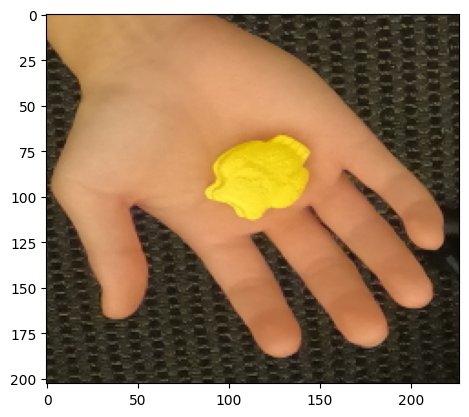

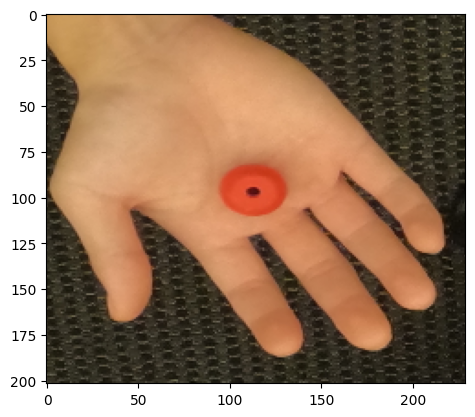

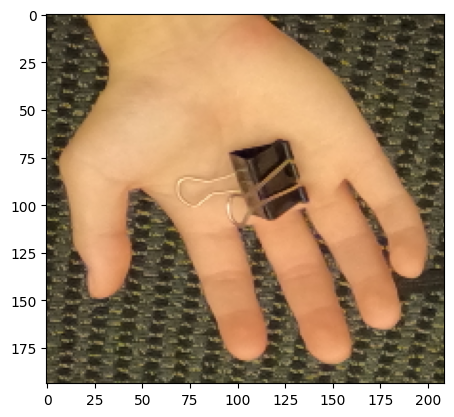

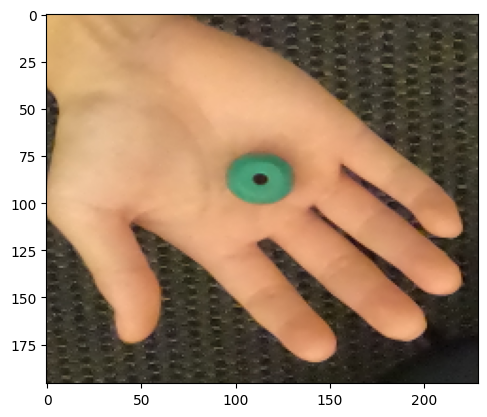

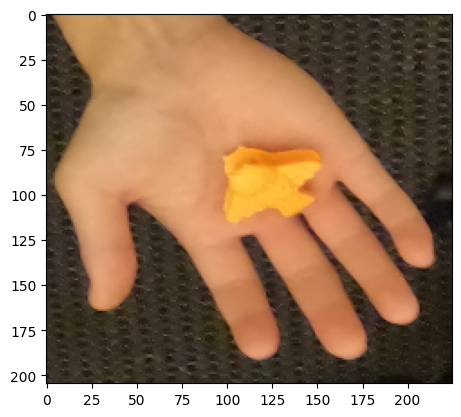

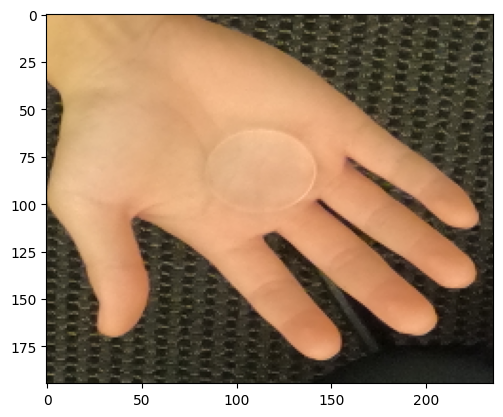

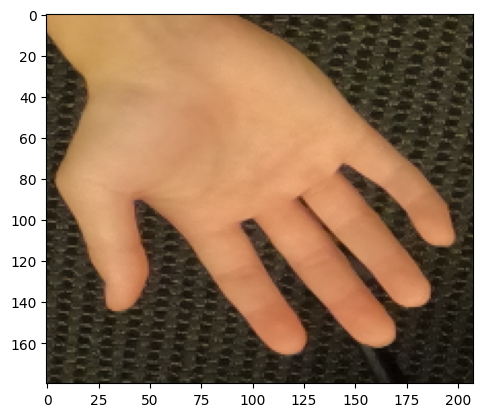

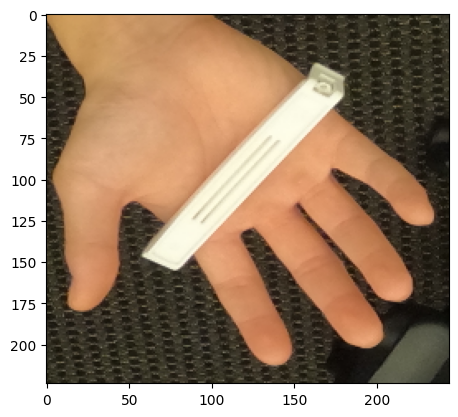

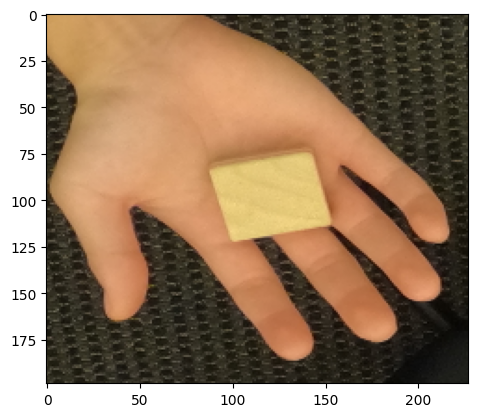

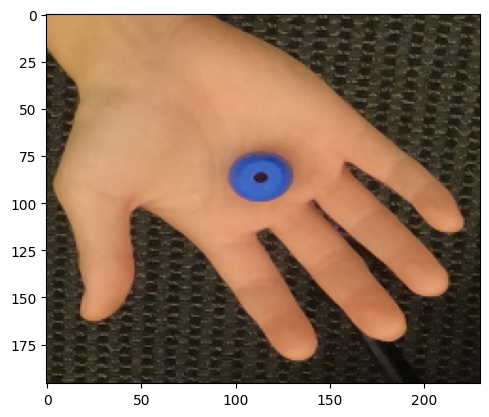

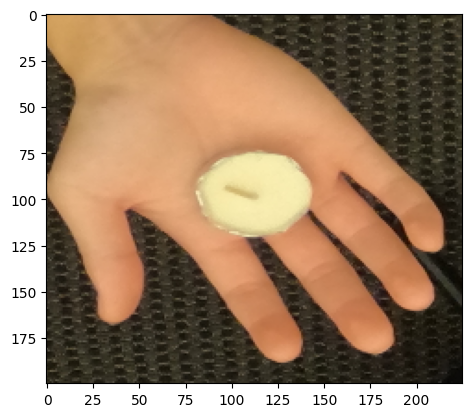

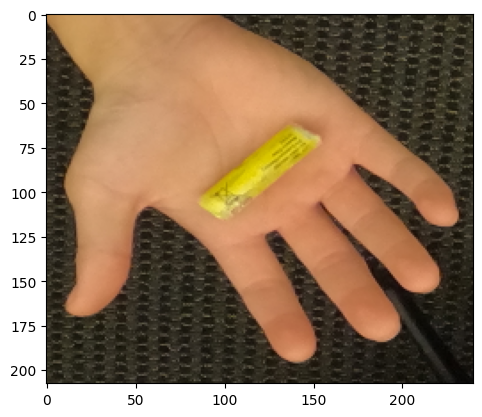

Shortest Distances: [[0.7430512, 0], [0.755901, 1], [0.7430512, 2], [0.7827394, 3], [0.7720893, 4], [0.7406078, 5], [0.73869103, 6], [0.7800986, 7], [0.76994824, 8], [0.755901, 9], [0.7917168, 10], [0.73869103, 11], [0.77715755, 12], [0.8089562, 13]]
Farthest Distances: [[0.88420105, 0], [0.8860115, 1], [0.924734, 2], [0.9350961, 3], [0.86749804, 4], [0.9394615, 5], [0.924734, 6], [0.8700151, 7], [0.8705657, 8], [0.89173526, 9], [0.8984946, 10], [0.9394615, 11], [0.878188, 12], [0.8984946, 13]]


In [14]:
import torch
from transformers import AutoModel, AutoProcessor
from transformers.image_utils import load_image
import os
import numpy as np
from matplotlib import pyplot as plt
import cv2

model = AutoModel.from_pretrained(MODEL, device_map="auto").eval()
processor = AutoProcessor.from_pretrained(MODEL)

# images = [load_image(f"../../images/pick_items/{image}") for image in os.listdir("../../images/pick-items")]

# Form a box around the hand
images = []
for f in os.listdir("../../images/pick-items"):
    image = cv2.imread(f"../../images/pick-items/{f}")
    image = cv2.resize(image, (1920, 1080))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = segment_hand(image)
    images.append(image)

# Show the images
for image in images:
    plt.imshow(image)
    plt.show()

inputs = processor(images=images, return_tensors="pt").to(model.device)

with torch.no_grad():
    # outputs = model(**inputs)
    # embeddings = outputs.last_hidden_state.mean(dim=1)
    embeddings = model.get_image_features(**inputs)

# embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
embeddings = embeddings.numpy()

shortest_distances = []
for i in range(len(images)):
    shortest_distance = [1e99, -1]
    for j in range(len(images)):
        if i == j:
            continue
        dist = cosine_similarity(embeddings[j], embeddings[i])
        if dist < shortest_distance[0]:
            shortest_distance = [dist, i]
    shortest_distances.append(shortest_distance)

print(f"Shortest Distances: {shortest_distances}")

farthest_distances = []
for i in range(len(images)):
    farthest_distance = [-1e99, -1]
    for j in range(len(images)):
        if i == j:
            continue
        dist = cosine_similarity(embeddings[j], embeddings[i])
        if dist > farthest_distance[0]:
            farthest_distance = [dist, i]
    farthest_distances.append(farthest_distance)

print(f"Farthest Distances: {farthest_distances}")

# Different Backgrounds

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

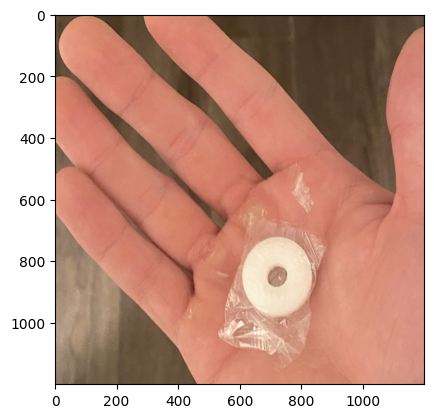

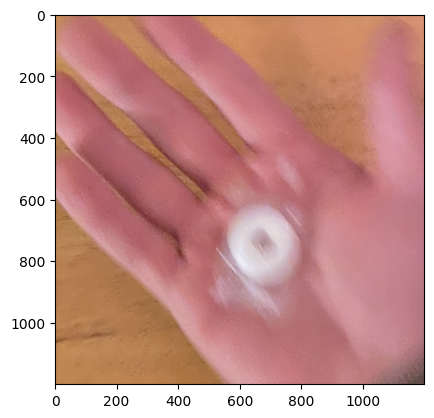

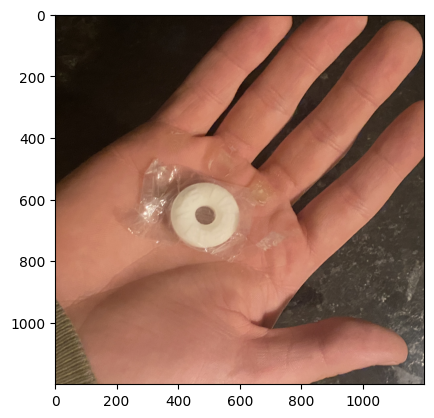

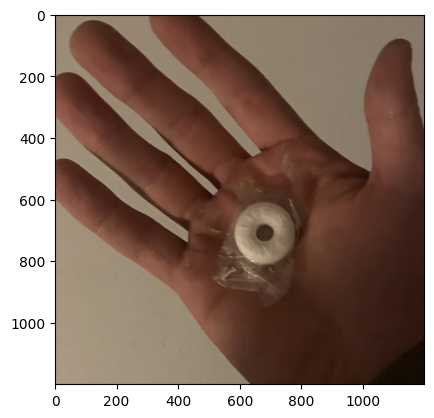

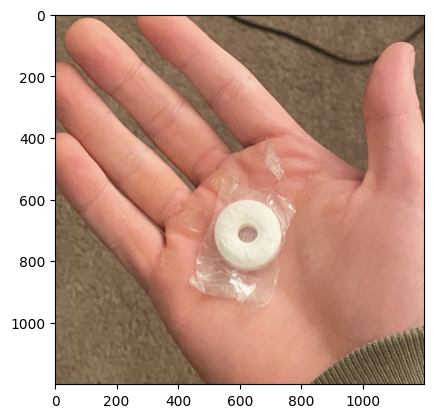

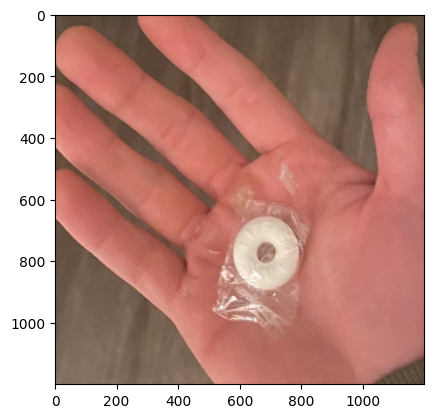

Shortest Distances: [[0.88427746, 0], [0.85892475, 1], [0.89402664, 2], [0.8819832, 3], [0.85892475, 4], [0.88613975, 5]]
Farthest Distances: [[0.96106017, 0], [0.89402664, 1], [0.94494104, 2], [0.92613876, 3], [0.94494104, 4], [0.96106017, 5]]


In [15]:
import torch
from transformers import AutoModel, AutoProcessor
import os
import numpy as np
from matplotlib import pyplot as plt
import cv2

model = AutoModel.from_pretrained(MODEL, device_map="auto").eval()
processor = AutoProcessor.from_pretrained(MODEL)

images = []
for f in os.listdir("../../images/background-test"):
    image = cv2.imread(f"../../images/background-test/{f}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = segment_hand(image)
    image = cv2.resize(image, (1200, 1200))
    images.append(image)

# Show the images
for image in images:
    plt.imshow(image)
    plt.show()

inputs = processor(images=images, return_tensors="pt").to(model.device)

with torch.no_grad():
    # outputs = model(**inputs)
    # embeddings = outputs.last_hidden_state.mean(dim=1)
    embeddings = model.get_image_features(**inputs)

# embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
embeddings = embeddings.numpy()

shortest_distances = []
for i in range(len(images)):
    shortest_distance = [1e99, -1]
    for j in range(len(images)):
        if i == j:
            continue
        dist = cosine_similarity(embeddings[j], embeddings[i])
        if dist < shortest_distance[0]:
            shortest_distance = [dist, i]
    shortest_distances.append(shortest_distance)

print(f"Shortest Distances: {shortest_distances}")

farthest_distances = []
for i in range(len(images)):
    farthest_distance = [-1e99, -1]
    for j in range(len(images)):
        if i == j:
            continue
        dist = cosine_similarity(embeddings[j], embeddings[i])
        if dist > farthest_distance[0]:
            farthest_distance = [dist, i]
    farthest_distances.append(farthest_distance)

print(f"Farthest Distances: {farthest_distances}")

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

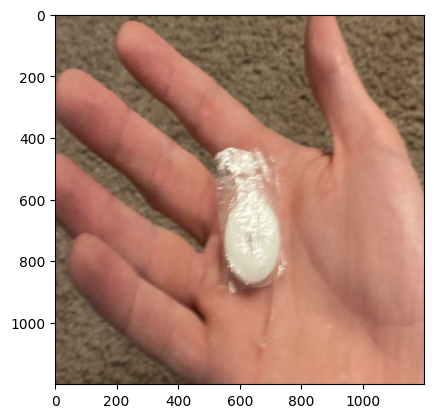

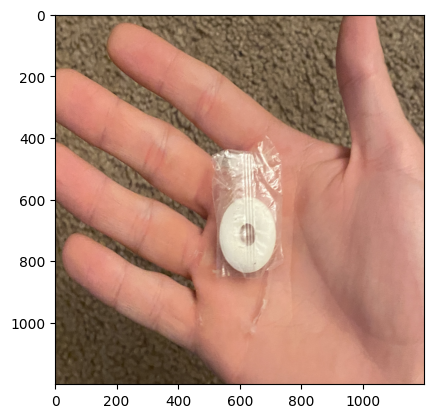

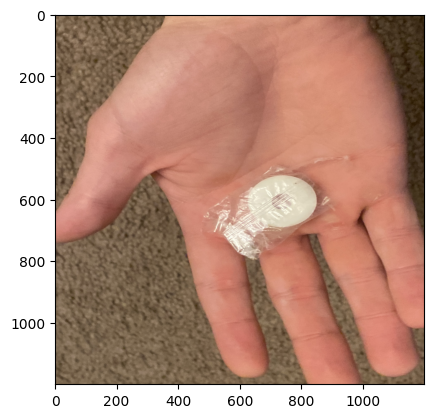

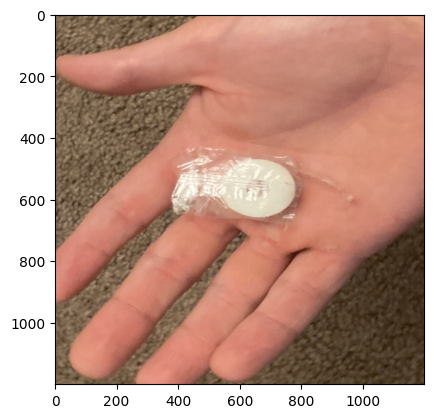

Shortest Distances: [[0.8757443, 0], [0.86617696, 1], [0.9017326, 2], [0.86617696, 3]]
Farthest Distances: [[0.9150513, 0], [0.9017326, 1], [0.9172542, 2], [0.9172542, 3]]


In [16]:
import torch
from transformers import AutoModel, AutoProcessor
import os
import numpy as np
from matplotlib import pyplot as plt
import cv2

model = AutoModel.from_pretrained(MODEL, device_map="auto").eval()
processor = AutoProcessor.from_pretrained(MODEL)

images = []
for f in os.listdir("../../images/orientation-test"):
    image = cv2.imread(f"../../images/orientation-test/{f}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = segment_hand(image)
    image = cv2.resize(image, (1200, 1200))
    images.append(image)

# Show the images
for image in images:
    plt.imshow(image)
    plt.show()

inputs = processor(images=images, return_tensors="pt").to(model.device)

with torch.no_grad():
    # outputs = model(**inputs)
    # embeddings = outputs.last_hidden_state.mean(dim=1)
    embeddings = model.get_image_features(**inputs)

# embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
embeddings = embeddings.numpy()

shortest_distances = []
for i in range(len(images)):
    shortest_distance = [1e99, -1]
    for j in range(len(images)):
        if i == j:
            continue
        dist = cosine_similarity(embeddings[j], embeddings[i])
        if dist < shortest_distance[0]:
            shortest_distance = [dist, i]
    shortest_distances.append(shortest_distance)

print(f"Shortest Distances: {shortest_distances}")

farthest_distances = []
for i in range(len(images)):
    farthest_distance = [-1e99, -1]
    for j in range(len(images)):
        if i == j:
            continue
        dist = cosine_similarity(embeddings[j], embeddings[i])
        if dist > farthest_distance[0]:
            farthest_distance = [dist, i]
    farthest_distances.append(farthest_distance)

print(f"Farthest Distances: {farthest_distances}")

# Embedding Picklists

In [25]:
import torch
from transformers import AutoModel, AutoProcessor
import os
import numpy as np
import cv2
import chromadb

model = AutoModel.from_pretrained(MODEL, device_map="auto").eval()
processor = AutoProcessor.from_pretrained(MODEL)
chroma_client = chromadb.Client()

chroma_client.delete_collection(name="embedding_picklist_test")
collection = chroma_client.create_collection(
    name="embedding_picklist_test",
    configuration={
        "hnsw": {
            "space": "cosine"
        }
    },
    metadata={
        "description": "test database for testing my model's ability to map images to names"
    }
)
id = 1

In [7]:
def embed(image, picklist, id: int, model, processor, collection):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = segment_hand(image)
    if image is None:
        print("Unable to Segment Image")
        return
    inputs = processor(images=[image], return_tensors="pt").to(model.device)
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs)
    collection.add(
        ids=[f"id{id}"],
        embeddings=embeddings.numpy(),
        metadatas=[{"picklist": picklist}]
    )
    return embeddings.numpy()

In [32]:
picklists = ["gbr", "b", "br"]

# Embed picklists
for (i, picklist) in enumerate(picklists):
    for f in os.listdir(f"../../images/picklist-test/{i}"):
        image = cv2.imread(f"../../images/picklist-test/{i}/{f}")
        embed(image, picklist, id)
        id += 1


libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

In [34]:
image = cv2.imread("../../images/picklist-test/test/b.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = segment_hand(image)
query = None
if image is not None:
    inputs = processor(images=[image], return_tensors="pt").to(model.device)
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs)
    query = collection.query(
        query_embeddings=embeddings.numpy(),
    )
else:
    print("Could not find hands")
print(query)

{'ids': [['id1', 'id5', 'id4', 'id3', 'id6', 'id2']], 'embeddings': None, 'documents': [[None, None, None, None, None, None]], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'picklist': 'gbr'}, {'picklist': 'br'}, {'picklist': 'b'}, {'picklist': 'gbr'}, {'picklist': 'br'}, {'picklist': 'gbr'}]], 'distances': [[0.08089715242385864, 0.08145791292190552, 0.09052234888076782, 0.15679407119750977, 0.17583853006362915, 0.18386977910995483]]}


libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

In [35]:
image = cv2.imread("../../images/picklist-test/test/r.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = segment_hand(image)
query = None
if image is not None:
    inputs = processor(images=[image], return_tensors="pt").to(model.device)
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs)
    query = collection.query(
        query_embeddings=embeddings.numpy(),
    )
else:
    print("Could not find hands")
print(query)

{'ids': [['id2', 'id6', 'id3', 'id1', 'id5', 'id4']], 'embeddings': None, 'documents': [[None, None, None, None, None, None]], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'picklist': 'gbr'}, {'picklist': 'br'}, {'picklist': 'gbr'}, {'picklist': 'gbr'}, {'picklist': 'br'}, {'picklist': 'b'}]], 'distances': [[0.03382200002670288, 0.06773018836975098, 0.1235852837562561, 0.12804573774337769, 0.1506693959236145, 0.18710780143737793]]}


libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

In [37]:
image = cv2.imread("../../images/picklist-test/test/g.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = segment_hand(image)
query = None
if image is not None:
    inputs = processor(images=[image], return_tensors="pt").to(model.device)
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs)
    query = collection.query(
        query_embeddings=embeddings.numpy(),
    )
else:
    print("Could not find hands")
print(query)

{'ids': [['id3', 'id2', 'id1', 'id5', 'id6', 'id4']], 'embeddings': None, 'documents': [[None, None, None, None, None, None]], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'picklist': 'gbr'}, {'picklist': 'gbr'}, {'picklist': 'gbr'}, {'picklist': 'br'}, {'picklist': 'br'}, {'picklist': 'b'}]], 'distances': [[0.08080500364303589, 0.1520351767539978, 0.17952150106430054, 0.17982149124145508, 0.1873326301574707, 0.21146678924560547]]}


libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

# Creating heatmaps for our objects

In [9]:
from transformers import AutoModel, AutoProcessor
import chromadb

model = AutoModel.from_pretrained(MODEL, device_map="auto").eval()
processor = AutoProcessor.from_pretrained(MODEL)
chroma_client = chromadb.Client()

try:
    chroma_client.delete_collection(name="all_embeddings")
except:
    pass
collection = chroma_client.create_collection(
    name="all_embeddings",
    configuration={
        "hnsw": {
            "space": "cosine"
        }
    },
    metadata={
        "description": "test dataset for embedding all of the items we have"
    }
)
id = 1

In [11]:
import torch
import os
import cv2

def embed_and_process_img(image_name, id: int, model, processor, collection):
    image = cv2.imread(image_name)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = segment_hand(image)
    if image is None:
        print(f"Unable to segment image in {image_name}")
        return (None, None)
    inputs = processor(images=[image], return_tensors="pt").to(model.device)
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs)
    collection.add(
        ids=[f"id{id}"],
        embeddings=embeddings.numpy()
    )
    return (embeddings.numpy(), cv2.resize(image, (64, 64)))


embeddings = []
images = []
for f in os.listdir("../../images/our-items/"):
    print(f"Embedding: {f}")
    (embedding, image) = embed_and_process_img(f"../../images/our-items/{f}", id, model, processor, collection)
    if embedding is not None and image is not None:
        embeddings.append(embedding)
        images.append(image)
    id += 1

Embedding: red-bead.jpg


libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

Embedding: red-rectangle-gem.jpg


libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

Embedding: b-block.jpg


...

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

Embedding: binder-clip.jpg


libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

Embedding: g-block.jpg


libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open radeonsi: /usr/lib/dri/radeonsi_dri.so: cann

In [17]:
print(f"Embeddings: {len(embeddings)}, Images: {len(images)}")
images = np.array(images)

Embeddings: 124, Images: 124


In [14]:
cosine_similarities = np.zeros((len(embeddings), len(embeddings)))

for i in range(len(embeddings)):
    for j in range(len(embeddings)):
        cosine_similarities[i, j] = cosine_similarity(embeddings[i].reshape(512), embeddings[j].reshape(512))